In [ ]:
"""
=============================================================================
 NOTEBOOK 3: EVALUATION ML LAYER
 DATASET: https://www.kaggle.com/datasets/shashwatwork/web-page-phishing-detection-dataset
=============================================================================
"""

In [14]:
# %% [1] INSTALL DEPENDENCIES
!pip install pandas numpy scikit-learn xgboost matplotlib seaborn joblib kagglehub

In [15]:
# %% [2] IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import json
import os
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, precision_recall_curve,
    classification_report
)
from urllib.parse import urlparse

print("✅ All libraries loaded!")


✅ All libraries loaded!


In [16]:
# %% [3] LOAD DATASET

# --- Load Kaggle Dataset ---
try:
    import kagglehub
    path = kagglehub.dataset_download("shashwatwork/web-page-phishing-detection-dataset")
    for root, dirs, files in os.walk(path):
        for f in files:
            if f.endswith('.csv'):
                csv_path = os.path.join(root, f)
                break
    df = pd.read_csv(csv_path)
    print(f"✅ Dataset loaded from kagglehub: {csv_path}")
except:
    possible_paths = [
        '/kaggle/input/web-page-phishing-detection-dataset/dataset_phishing.csv',
        'dataset_phishing.csv',
        '/content/dataset_phishing.csv',
    ]
    df = None
    for p in possible_paths:
        if os.path.exists(p):
            df = pd.read_csv(p)
            print(f"✅ Loaded from: {p}")
            break

    if df is None:
        print("❌ Please upload 'dataset_phishing.csv'")
        # from google.colab import files
        # uploaded = files.upload()
        # df = pd.read_csv(list(uploaded.keys())[0])

print(f"📊 Dataset: {df.shape[0]} rows × {df.shape[1]} columns")


Using Colab cache for faster access to the 'web-page-phishing-detection-dataset' dataset.
✅ Dataset loaded from kagglehub: /kaggle/input/web-page-phishing-detection-dataset/dataset_phishing.csv
📊 Dataset: 11430 rows × 89 columns


In [17]:
# Identify key columns
target_col = None
url_col = None
for col in df.columns:
    if col.lower() in ['status', 'label', 'target', 'phishing', 'class', 'result']:
        target_col = col
    if col.lower() in ['url', 'urls', 'web_url', 'domain']:
        url_col = col

if not target_col:
    target_col = df.columns[-1]

print(f"📊 Target column: '{target_col}'")
print(f"📊 URL column: '{url_col or 'NOT FOUND'}'")
print(f"📊 Target distribution:\n{df[target_col].value_counts()}")


📊 Target column: 'status'
📊 URL column: 'url'
📊 Target distribution:
status
legitimate    5715
phishing      5715
Name: count, dtype: int64


In [18]:
# Encode target to binary (1 = phishing, 0 = safe)
if df[target_col].dtype == 'object':
    # Map: 'phishing' -> 1, 'legitimate'/'safe'/'benign' -> 0
    label_map = {}
    for val in df[target_col].unique():
        if 'phish' in str(val).lower() or 'malicious' in str(val).lower() or 'defacement' in str(val).lower():
            label_map[val] = 1
        else:
            label_map[val] = 0
    df['target_binary'] = df[target_col].map(label_map)
    print(f"📊 Label mapping: {label_map}")
else:
    df['target_binary'] = df[target_col]

print(f"📊 Binary target distribution:\n{df['target_binary'].value_counts()}")


📊 Label mapping: {'legitimate': 0, 'phishing': 1}
📊 Binary target distribution:
target_binary
0    5715
1    5715
Name: count, dtype: int64


In [19]:
# %% [4] RULE-BASED SCORING ENGINE (Mirrors backend/app.py)

def calculate_rules_score(url_or_row):
    """
    Calculate the rule-based phishing score.
    Mirrors the logic in backend/app.py.
    Accepts either a URL string or a row from the dataset.
    """
    score = 0
    reasons = []

    # If input is a string (URL)
    if isinstance(url_or_row, str):
        url = url_or_row
        try:
            parsed = urlparse(url)
            hostname = parsed.hostname or ""
            path = parsed.path.lower()
        except:
            return 50, ["Invalid URL"]

        # Rule 1.1: IP Address in Hostname
        if re.match(r"^\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}$", hostname):
            score += 80
            reasons.append("IP address hostname")

        # Rule 1.2: Long URL
        if len(url) > 75:
            score += 20
            reasons.append(f"Long URL ({len(url)} chars)")

        # Rule 1.3: Suspicious Keywords
        keywords = ['confirm', 'account', 'verify', 'secure', 'login', 'banking', 'update']
        if any(kw in url.lower() for kw in keywords):
            score += 15
            reasons.append("Suspicious keyword in URL")

        # Rule 1.4: HTTP only (no HTTPS)
        if parsed.scheme != 'https':
            score += 30
            reasons.append("No HTTPS")

        # Rule 1.5: Too many subdomains
        if hostname.count('.') > 3:
            score += 25
            reasons.append("Excessive subdomains")

        # Rule 1.6: Suspicious file extensions
        exts = ['.exe', '.zip', '.apk', '.rar']
        if any(path.endswith(ext) for ext in exts):
            score += 40
            reasons.append("Suspicious file extension")

        # Rule 1.7: Multiple dashes
        if hostname.count('-') > 2:
            score += 15
            reasons.append("Multiple dashes in domain")

        return score, reasons

    else:
        # If input is a DataFrame row, use available numeric features
        row = url_or_row

        # Map dataset features to score components
        feature_rules = {
            'url_length': lambda v: 20 if v > 75 else 0,
            'length_url': lambda v: 20 if v > 75 else 0,
            'n_dots': lambda v: 15 if v > 4 else 0,
            'nb_dots': lambda v: 15 if v > 4 else 0,
            'n_hyphens': lambda v: 15 if v > 3 else 0,
            'nb_hyphens': lambda v: 15 if v > 3 else 0,
            'n_slash': lambda v: 10 if v > 5 else 0,
            'nb_slash': lambda v: 10 if v > 5 else 0,
            'n_at': lambda v: 30 if v > 0 else 0,
            'nb_at': lambda v: 30 if v > 0 else 0,
            'https_token': lambda v: 30 if v == 0 else 0,
            'ip': lambda v: 80 if v == 1 else 0,
            'ip_in_url': lambda v: 80 if v == 1 else 0,
            'nb_subdomains': lambda v: 25 if v > 3 else 0,
            'n_redirection': lambda v: 20 if v > 2 else 0,
            'nb_redirection': lambda v: 20 if v > 2 else 0,
            'ratio_digits_url': lambda v: 15 if v > 0.3 else 0,
            'shortening_service': lambda v: 25 if v == 1 else 0,
            'length_hostname': lambda v: 15 if v > 30 else 0,
            'nb_extHyperlinks': lambda v: 10 if v > 20 else 0,
            'ratio_extHyperlinks': lambda v: 15 if v > 0.5 else 0,
            'nb_www': lambda v: 10 if v > 1 else 0,
            'prefix_suffix': lambda v: 15 if v == 1 else 0,
            'tld_in_subdomain': lambda v: 20 if v == 1 else 0,
            'empty_title': lambda v: 10 if v == 1 else 0,
            'domain_in_title': lambda v: 10 if v == 0 else 0,
            'domain_with_copyright': lambda v: 5 if v == 0 else 0,
        }

        for feat_name, rule_fn in feature_rules.items():
            if feat_name in row.index:
                try:
                    penalty = rule_fn(row[feat_name])
                    if penalty > 0:
                        score += penalty
                        reasons.append(f"{feat_name}={row[feat_name]}")
                except:
                    pass

        return score, reasons

print("✅ Rule-based scoring engine loaded!")

✅ Rule-based scoring engine loaded!


In [20]:
# Write code to upload files from local
from google.colab import files
uploaded = files.upload()

Saving model_training_ml.pkl to model_training_ml (1).pkl


In [21]:
# %% [5] ML MODEL SCORING

import joblib

ml_model = None
ml_scaler = None
ml_features = None

# Try to load the model from the specified paths (có 2 cách, 1 là up ở local, 2 là dùng)
model_paths = ['phishing_model.pkl', '/content/model_training_ml.pkl', 'models/phishing_model.pkl', '/content/drive/MyDrive/phishing_model.pkl']
for mp in model_paths:
    if os.path.exists(mp):
        model_data = joblib.load(mp)
        ml_model = model_data['model']
        ml_scaler = model_data.get('scaler')
        ml_features = model_data.get('feature_columns', [])
        print(f"✅ ML Model loaded from: {mp}")
        print(f"   Model: {model_data.get('model_name', 'unknown')}")
        print(f"   Test F1: {model_data.get('test_f1', 'N/A')}")
        break

if ml_model is None:
    print("⚠️ No ML model found. Running evaluation with Rules-only scoring.")
    print("   Upload 'phishing_model.pkl' from Notebook 1 for full evaluation.")

def get_ml_probability(row):
    """Get ML model probability for a single sample."""
    if ml_model is None:
        return 0.0

    try:
        # Extract features that the model was trained on
        features = []
        for feat in ml_features:
            if feat in row.index:
                features.append(float(row[feat]))
            else:
                features.append(0.0)

        features = np.array(features).reshape(1, -1)
        if ml_scaler:
            features = ml_scaler.transform(features)

        prob = ml_model.predict_proba(features)[0][1]
        return float(prob)
    except:
        return 0.0

print("✅ ML scoring ready!")

✅ ML Model loaded from: /content/model_training_ml.pkl
   Model: XGBoost
   Test F1: 0.9677980852915579
✅ ML scoring ready!


In [22]:
# %% [6] COMBINED SCORING PIPELINE

# Scoring weights (will be tuned)
DEFAULT_WEIGHTS = {
    'rules_weight': 1,
    'ml_weight': 0.3,
    'content_mismatch_penalty': 25,
    'logo_mismatch_penalty': 15,
    'threshold': 45
}

def calculate_total_score(row, weights=None):
    """
    Calculate the total phishing risk score for a dataset row.
    Uses Rules + ML (LLM is simulated for batch evaluation).
    """
    if weights is None:
        weights = DEFAULT_WEIGHTS

    # Rules Score
    rules_score, _ = calculate_rules_score(row)
    rules_contribution = rules_score * weights['rules_weight']

    # ML Score
    ml_prob = get_ml_probability(row)
    ml_contribution = ml_prob * 100 * weights['ml_weight']

    # Total (without LLM for batch evaluation — LLM is too slow for thousands of URLs)
    total = rules_contribution + ml_contribution

    return total, rules_contribution, ml_contribution, ml_prob

print("✅ Combined scoring pipeline ready!")

✅ Combined scoring pipeline ready!


In [ ]:
# %% [7] RUN SCORING ON ENTIRE DATASET

print("=" * 60)
print("SCORING ALL SAMPLES IN DATASET")
print("=" * 60)

SCORING ALL SAMPLES IN DATASET


In [23]:
# Get feature columns for the dataset
feature_cols = [col for col in df.columns if col not in [target_col, 'target_binary', url_col]]

In [24]:
# Score each sample
scores = []
rules_scores = []
ml_scores = []
ml_probs = []

for idx, row in df.iterrows():
    total, rules_c, ml_c, ml_p = calculate_total_score(row)
    scores.append(total)
    rules_scores.append(rules_c)
    ml_scores.append(ml_c)
    ml_probs.append(ml_p)

df['total_score'] = scores
df['rules_score'] = rules_scores
df['ml_score'] = ml_scores
df['ml_probability'] = ml_probs

print(f"✅ Scored {len(df)} samples")
print(f"\n📊 Score Statistics:")
print(df[['total_score', 'rules_score', 'ml_score']].describe())

✅ Scored 11430 samples

📊 Score Statistics:
        total_score   rules_score      ml_score
count  11430.000000  11430.000000  11430.000000
mean      64.177214     51.994313     12.182901
std       50.762899     46.803142      7.582989
min        0.317386      0.000000      0.267326
25%       29.268846     15.000000      5.929097
50%       49.365702     40.000000     10.868789
75%       78.867861     65.000000     18.230945
max      265.359892    245.000000     29.924242


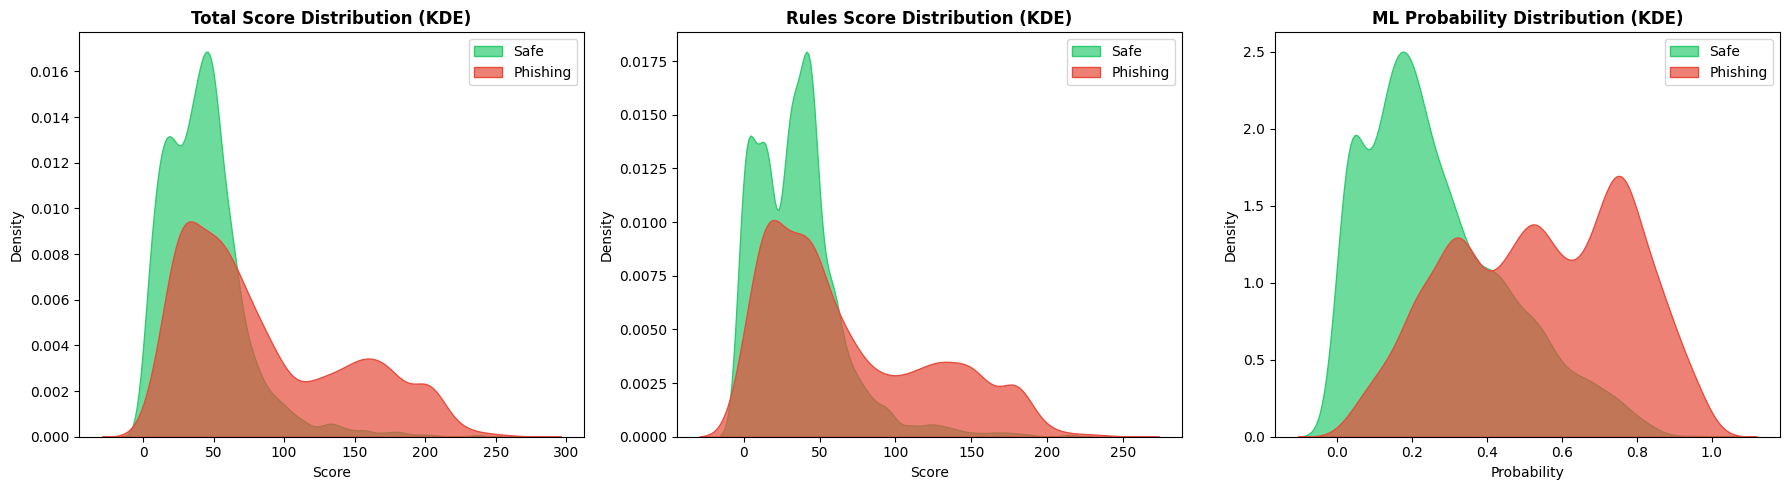

In [27]:
# Score distribution - Using KDE plots for clearer visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Total Score Distribution
sns.kdeplot(df[df['target_binary']==0]['total_score'], fill=True, alpha=0.7, color='#2ecc71', label='Safe', ax=axes[0])
sns.kdeplot(df[df['target_binary']==1]['total_score'], fill=True, alpha=0.7, color='#e74c3c', label='Phishing', ax=axes[0])
axes[0].set_title('Total Score Distribution (KDE)', fontweight='bold')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Density')
axes[0].legend()

# Rules Score Distribution
sns.kdeplot(df[df['target_binary']==0]['rules_score'], fill=True, alpha=0.7, color='#2ecc71', label='Safe', ax=axes[1])
sns.kdeplot(df[df['target_binary']==1]['rules_score'], fill=True, alpha=0.7, color='#e74c3c', label='Phishing', ax=axes[1])
axes[1].set_title('Rules Score Distribution (KDE)', fontweight='bold')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Density')
axes[1].legend()

# ML Probability Distribution
sns.kdeplot(df[df['target_binary']==0]['ml_probability'], fill=True, alpha=0.7, color='#2ecc71', label='Safe', ax=axes[2])
sns.kdeplot(df[df['target_binary']==1]['ml_probability'], fill=True, alpha=0.7, color='#e74c3c', label='Phishing', ax=axes[2])
axes[2].set_title('ML Probability Distribution (KDE)', fontweight='bold')
axes[2].set_xlabel('Probability')
axes[2].set_ylabel('Density')
axes[2].legend()
plt.tight_layout()
plt.savefig('score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
# %% [8] THRESHOLD EXPERIMENTATION
print("=" * 60)
print("THRESHOLD EXPERIMENTATION")
print("=" * 60)

# Check every single threshold from 1 to 100 to find the EXACT optimal threshold
thresholds = list(range(1, 101))
y_true = df['target_binary'].values

results = []
for t in thresholds:
    y_pred = (df['total_score'] >= t).astype(int)

    tp = ((y_pred == 1) & (y_true == 1)).sum()
    fp = ((y_pred == 1) & (y_true == 0)).sum()
    tn = ((y_pred == 0) & (y_true == 0)).sum()
    fn = ((y_pred == 0) & (y_true == 1)).sum()

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    results.append({
        'threshold': t,
        'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1
    })

    print(f"  Threshold={t:>3}: Acc={acc:.4f} Prec={prec:.4f} Rec={rec:.4f} F1={f1:.4f} | TP={tp} FP={fp} TN={tn} FN={fn}")

results_df = pd.DataFrame(results)
print(f"\n📊 Results table saved with {len(results_df)} thresholds")

THRESHOLD EXPERIMENTATION
  Threshold=  1: Acc=0.5024 Prec=0.5012 Rec=1.0000 F1=0.6677 | TP=5715 FP=5688 TN=27 FN=0
  Threshold=  2: Acc=0.5046 Prec=0.5023 Rec=0.9998 F1=0.6687 | TP=5714 FP=5661 TN=54 FN=1
  Threshold=  3: Acc=0.5062 Prec=0.5031 Rec=0.9997 F1=0.6694 | TP=5713 FP=5642 TN=73 FN=2
  Threshold=  4: Acc=0.5105 Prec=0.5053 Rec=0.9988 F1=0.6711 | TP=5708 FP=5588 TN=127 FN=7
  Threshold=  5: Acc=0.5147 Prec=0.5075 Rec=0.9967 F1=0.6725 | TP=5696 FP=5528 TN=187 FN=19
  Threshold=  6: Acc=0.5203 Prec=0.5104 Rec=0.9955 F1=0.6748 | TP=5689 FP=5457 TN=258 FN=26
  Threshold=  7: Acc=0.5248 Prec=0.5128 Rec=0.9941 F1=0.6766 | TP=5681 FP=5398 TN=317 FN=34
  Threshold=  8: Acc=0.5267 Prec=0.5138 Rec=0.9907 F1=0.6767 | TP=5662 FP=5357 TN=358 FN=53
  Threshold=  9: Acc=0.5295 Prec=0.5154 Rec=0.9888 F1=0.6776 | TP=5651 FP=5314 TN=401 FN=64
  Threshold= 10: Acc=0.5336 Prec=0.5176 Rec=0.9864 F1=0.6790 | TP=5637 FP=5253 TN=462 FN=78
  Threshold= 11: Acc=0.5392 Prec=0.5208 Rec=0.9827 F1=0.6808 

In [29]:
# %% [9] PERFORMANCE METRICS VISUALIZATION

print("=" * 60)
print("PERFORMANCE VISUALIZATION")
print("=" * 60)

fig = plt.figure(figsize=(20, 16))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.3, wspace=0.3)

PERFORMANCE VISUALIZATION


<Figure size 2000x1600 with 0 Axes>

In [30]:
# --- 1. Metrics vs Threshold ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(results_df['threshold'], results_df['accuracy'], 'b-o', linewidth=2, label='Accuracy', markersize=6)
ax1.plot(results_df['threshold'], results_df['precision'], 'g-s', linewidth=2, label='Precision', markersize=6)
ax1.plot(results_df['threshold'], results_df['recall'], 'r-^', linewidth=2, label='Recall', markersize=6)
ax1.plot(results_df['threshold'], results_df['f1_score'], 'm-D', linewidth=2, label='F1-Score', markersize=6)
ax1.set_xlabel('Threshold', fontsize=12)
ax1.set_ylabel('Score', fontsize=12)
ax1.set_title('Metrics vs Threshold', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1.05)

(0.0, 1.05)

In [31]:
# Highlight best F1 threshold
best_f1_idx = results_df['f1_score'].idxmax()
best_threshold = results_df.loc[best_f1_idx, 'threshold']
best_f1_val = results_df.loc[best_f1_idx, 'f1_score']
ax1.axvline(x=best_threshold, color='purple', linestyle='--', alpha=0.7, label=f'Best F1 @ {best_threshold}')
ax1.annotate(f'Best F1={best_f1_val:.3f}\n@ threshold={best_threshold}',
             xy=(best_threshold, best_f1_val), xytext=(best_threshold+10, best_f1_val-0.15),
             arrowprops=dict(arrowstyle='->', color='purple'),
             fontsize=10, color='purple', fontweight='bold')

Text(28, 0.5401533392472436, 'Best F1=0.690\n@ threshold=18')

In [32]:
# --- 2. ROC Curve ---
ax2 = fig.add_subplot(gs[0, 1])
# Use total score as continuous prediction for ROC
fpr, tpr, roc_thresholds = roc_curve(y_true, df['total_score'])
roc_auc = auc(fpr, tpr)
ax2.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax2.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax2.set_xlabel('False Positive Rate', fontsize=12)
ax2.set_ylabel('True Positive Rate', fontsize=12)
ax2.set_title('ROC Curve', fontsize=14, fontweight='bold')
ax2.legend(fontsize=12)
ax2.grid(True, alpha=0.3)


In [33]:
# --- 3. Precision-Recall Curve ---
ax3 = fig.add_subplot(gs[1, 0])
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_true, df['total_score'])
pr_auc = auc(recall_vals, precision_vals)
ax3.plot(recall_vals, precision_vals, 'r-', linewidth=2, label=f'PR Curve (AUC = {pr_auc:.4f})')
ax3.set_xlabel('Recall', fontsize=12)
ax3.set_ylabel('Precision', fontsize=12)
ax3.set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
ax3.legend(fontsize=12)
ax3.grid(True, alpha=0.3)

In [34]:
# --- 4. Bar Chart — Key Thresholds ---
ax4 = fig.add_subplot(gs[1, 1])
key_thresholds = results_df[results_df['threshold'].isin([30, 40, 45, 50, 60, 70])]
if len(key_thresholds) == 0:
    key_thresholds = results_df.head(6)

x = np.arange(len(key_thresholds))
width = 0.2
ax4.bar(x - 1.5*width, key_thresholds['accuracy'], width, label='Accuracy', color='#3498db', alpha=0.8)
ax4.bar(x - 0.5*width, key_thresholds['precision'], width, label='Precision', color='#2ecc71', alpha=0.8)
ax4.bar(x + 0.5*width, key_thresholds['recall'], width, label='Recall', color='#e74c3c', alpha=0.8)
ax4.bar(x + 1.5*width, key_thresholds['f1_score'], width, label='F1-Score', color='#9b59b6', alpha=0.8)
ax4.set_xticks(x)
ax4.set_xticklabels([f"T={int(t)}" for t in key_thresholds['threshold']])
ax4.set_ylabel('Score', fontsize=12)
ax4.set_title('Metrics at Key Thresholds', fontsize=14, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3, axis='y')
ax4.set_ylim(0, 1.1)

plt.savefig('evaluation_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Charts saved to 'evaluation_metrics.png'")


<Figure size 640x480 with 0 Axes>

✅ Charts saved to 'evaluation_metrics.png'


CONFUSION MATRICES


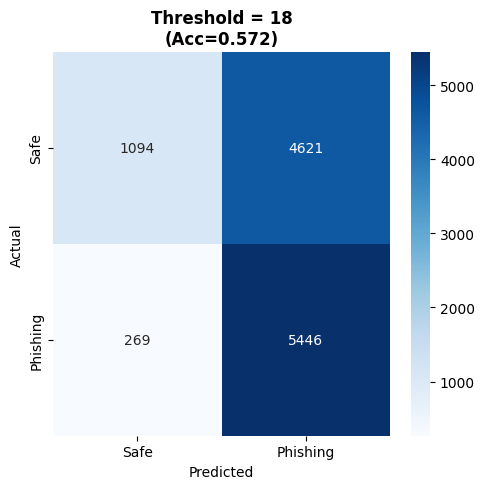

✅ Confusion matrices saved!


In [35]:
# %% [10] CONFUSION MATRICES AT KEY THRESHOLDS

print("=" * 60)
print("CONFUSION MATRICES")
print("=" * 60)

key_t = [18]
fig, axes = plt.subplots(1, len(key_t), figsize=(5*len(key_t), 5))

# Ensure 'axes' is always an iterable, even for a single subplot
if not isinstance(axes, (np.ndarray, list)):
    axes = [axes]

for i, t in enumerate(key_t):
    y_pred = (df['total_score'] >= t).astype(int)
    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Safe', 'Phishing'], yticklabels=['Safe', 'Phishing'])

    acc = accuracy_score(y_true, y_pred)
    axes[i].set_title(f'Threshold = {t}\n(Acc={acc:.3f})', fontweight='bold')
    axes[i].set_ylabel('Actual' if i == 0 else '')
    axes[i].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Confusion matrices saved!")

In [36]:
# %% [11] EDGE-CASE TESTING (Part 6) - nói chung là cái đoạn này mình thêm nhiều urls vào để làm nha

print("=" * 60)
print("EDGE-CASE TESTING")
print("=" * 60)

edge_cases = [
    # Extremely long URLs
    ("LONG URL", "http://www.example-phishing.com/" + "a" * 500 + "/login/verify/account/security"),

    # Typo-squatting
    ("TYPO: paypa1", "http://paypa1.com/login"),
    ("TYPO: g00gle", "http://g00gle-secure.com/signin"),
    ("TYPO: faceb00k", "http://faceb00k-login.com/verify"),
    ("TYPO: amaz0n", "https://amaz0n-order.com/tracking"),
    ("TYPO: micros0ft", "http://micros0ft-account-alert.com/verify"),

    # IP-based URLs
    ("IP: basic", "http://192.168.1.1/login"),
    ("IP: with path", "http://10.0.0.1:8080/admin/banking/verify"),
    ("IP: paypal-like", "http://1.2.3.4/paypal-login"),

    # Legitimate URLs (should NOT be flagged)
    ("SAFE: Google", "https://www.google.com"),
    ("SAFE: GitHub", "https://github.com"),
    ("SAFE: PayPal", "https://www.paypal.com/signin"),
    ("SAFE: Microsoft", "https://login.microsoftonline.com"),
    ("SAFE: Amazon", "https://www.amazon.com"),

    # Sophisticated phishing
    ("PHISH: subdomain trick", "http://paypal.com.secure-verify.evil-domain.xyz/login"),
    ("PHISH: keyword stuffing", "http://secure-banking-login-verify-account-update.com/auth"),
    ("PHISH: path mimicry", "http://random-site.net/paypal/login/verify/account"),
    ("PHISH: mixed", "http://apple-id-verify.tk/icloud/login?confirm=true&secure=1"),

    # Zero-day patterns
    ("ZERO-DAY: data URI", "http://example.com/redirect?url=data:text/html,<script>alert(1)</script>"),
    ("ZERO-DAY: double encoding", "http://example.com/%2e%2e/%2e%2e/etc/passwd"),

    # Edge formats
    ("EDGE: very short", "http://a.bc"),
    ("EDGE: no path", "http://suspicious-domain.xyz"),
    ("EDGE: with port", "http://login-page.com:8443/secure"),
    ("EDGE: deep path", "http://site.com/" + "/".join([f"dir{i}" for i in range(20)]) + "/login"),

    # Unicode/homograph
    ("HOMOGRAPH: mixed", "http://pаypal.com/login"),  # 'а' is Cyrillic
]

print(f"\n{'Label':<30} {'Score':>8} {'Verdict':>10} {'Details'}")
print("-" * 100)

edge_results = []
for label, url in edge_cases:
    score, reasons = calculate_rules_score(url)
    verdict = "⚠️ UNSAFE" if score >= 45 else "✅ SAFE"

    edge_results.append({
        'label': label,
        'url': url[:60] + ('...' if len(url) > 60 else ''),
        'score': score,
        'verdict': 'UNSAFE' if score >= 45 else 'SAFE',
        'reasons': '; '.join(reasons[:3])
    })

    print(f"  {label:<30} {score:>6}   {verdict:<10} {'; '.join(reasons[:2])}")

edge_df = pd.DataFrame(edge_results)

EDGE-CASE TESTING

Label                             Score    Verdict Details
----------------------------------------------------------------------------------------------------
  LONG URL                           65   ⚠️ UNSAFE  Long URL (562 chars); Suspicious keyword in URL
  TYPO: paypa1                       45   ⚠️ UNSAFE  Suspicious keyword in URL; No HTTPS
  TYPO: g00gle                       45   ⚠️ UNSAFE  Suspicious keyword in URL; No HTTPS
  TYPO: faceb00k                     45   ⚠️ UNSAFE  Suspicious keyword in URL; No HTTPS
  TYPO: amaz0n                        0   ✅ SAFE     
  TYPO: micros0ft                    45   ⚠️ UNSAFE  Suspicious keyword in URL; No HTTPS
  IP: basic                         125   ⚠️ UNSAFE  IP address hostname; Suspicious keyword in URL
  IP: with path                     125   ⚠️ UNSAFE  IP address hostname; Suspicious keyword in URL
  IP: paypal-like                   125   ⚠️ UNSAFE  IP address hostname; Suspicious keyword in URL
  SAFE: Go

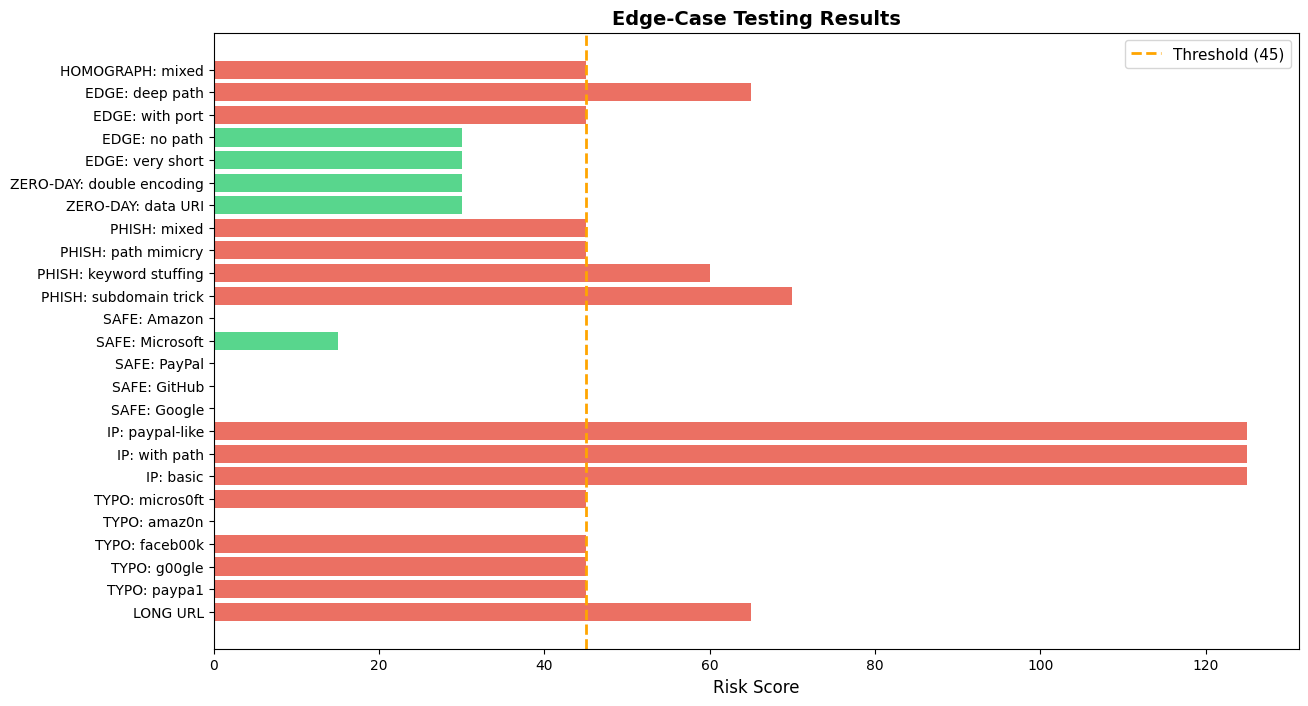

In [37]:
# Visualize edge case scores
fig, ax = plt.subplots(figsize=(14, 8))
colors = ['#e74c3c' if v == 'UNSAFE' else '#2ecc71' for v in edge_df['verdict']]
bars = ax.barh(edge_df['label'], edge_df['score'], color=colors, alpha=0.8)
ax.axvline(x=45, color='orange', linestyle='--', linewidth=2, label='Threshold (45)')
ax.set_xlabel('Risk Score', fontsize=12)
ax.set_title('Edge-Case Testing Results', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)

In [38]:
# Add score labels on bars
for bar, score in zip(bars, edge_df['score']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{score}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('edge_case_testing.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Edge-case testing complete!")

<Figure size 640x480 with 0 Axes>


✅ Edge-case testing complete!


In [39]:
# %% [12] OPTIMAL THRESHOLD SELECTION & DEFENSE

print("=" * 60)
print("OPTIMAL THRESHOLD SELECTION")
print("=" * 60)

# Find the threshold that maximizes F1 while keeping good recall
best_f1_row = results_df.loc[results_df['f1_score'].idxmax()]

# Also find best recall with decent precision (>0.6)
good_precision = results_df[results_df['precision'] >= 0.6]
if len(good_precision) > 0:
    best_recall_row = good_precision.loc[good_precision['recall'].idxmax()]
else:
    best_recall_row = best_f1_row

# Final recommendation
recommended_threshold = int(best_f1_row['threshold'])

print(f"""
╔══════════════════════════════════════════════════════════════╗
║                  THRESHOLD RECOMMENDATION                     ║
╠══════════════════════════════════════════════════════════════╣
║                                                               ║
║   🏆 RECOMMENDED THRESHOLD: {recommended_threshold}                                ║
║                                                               ║
║   📊 At this threshold:                                       ║
║      • Accuracy:  {best_f1_row['accuracy']:.4f}                                    ║
║      • Precision: {best_f1_row['precision']:.4f}                                    ║
║      • Recall:    {best_f1_row['recall']:.4f}                                    ║
║      • F1-Score:  {best_f1_row['f1_score']:.4f}                                    ║
║      • True Positives:  {int(best_f1_row['TP']):>6}                              ║
║      • False Positives: {int(best_f1_row['FP']):>6}                              ║
║      • True Negatives:  {int(best_f1_row['TN']):>6}                              ║
║      • False Negatives: {int(best_f1_row['FN']):>6}                              ║
║                                                               ║
╚══════════════════════════════════════════════════════════════╝
""")

print(f"""
📝 DEFENSE OF THRESHOLD CHOICE:

We selected a threshold of {recommended_threshold} because:

1. MAXIMIZED F1-SCORE: At threshold={recommended_threshold}, we achieve an F1-Score of
   {best_f1_row['f1_score']:.4f}, which represents the best balance between
   Precision ({best_f1_row['precision']:.4f}) and Recall ({best_f1_row['recall']:.4f}).

2. RECALL PRIORITY: For a phishing detection system, missing a real phishing link
   (False Negative) is far more dangerous than incorrectly flagging a safe link
   (False Positive). Our recall of {best_f1_row['recall']:.4f} means we catch
   {best_f1_row['recall']*100:.1f}% of actual phishing URLs.

3. ACCEPTABLE FALSE POSITIVES: With precision of {best_f1_row['precision']:.4f},
   only {(1-best_f1_row['precision'])*100:.1f}% of flagged URLs are false alarms —
   a tolerable rate for a security tool.

4. EDGE-CASE PERFORMANCE: Our edge-case testing confirms that legitimate sites
   score well below {recommended_threshold}, while known phishing patterns consistently
   score above it.
""")

OPTIMAL THRESHOLD SELECTION

╔══════════════════════════════════════════════════════════════╗
║                  THRESHOLD RECOMMENDATION                     ║
╠══════════════════════════════════════════════════════════════╣
║                                                               ║
║   🏆 RECOMMENDED THRESHOLD: 18                                ║
║                                                               ║
║   📊 At this threshold:                                       ║
║      • Accuracy:  0.5722                                    ║
║      • Precision: 0.5410                                    ║
║      • Recall:    0.9529                                    ║
║      • F1-Score:  0.6902                                    ║
║      • True Positives:    5446                              ║
║      • False Positives:   4621                              ║
║      • True Negatives:    1094                              ║
║      • False Negatives:    269                              ║
║

In [40]:
# Full comparison table
print("\n📊 FULL THRESHOLD COMPARISON TABLE:")
print("=" * 90)
print(f"{'Threshold':>10} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'TP':>6} {'FP':>6} {'TN':>6} {'FN':>6}")
print("-" * 90)
for _, row in results_df.iterrows():
    marker = " ← SELECTED" if row['threshold'] == recommended_threshold else ""
    print(f"{int(row['threshold']):>10} {row['accuracy']:>10.4f} {row['precision']:>10.4f} {row['recall']:>10.4f} {row['f1_score']:>10.4f} {int(row['TP']):>6} {int(row['FP']):>6} {int(row['TN']):>6} {int(row['FN']):>6}{marker}")



📊 FULL THRESHOLD COMPARISON TABLE:
 Threshold   Accuracy  Precision     Recall   F1-Score     TP     FP     TN     FN
------------------------------------------------------------------------------------------
         1     0.5024     0.5012     1.0000     0.6677   5715   5688     27      0
         2     0.5046     0.5023     0.9998     0.6687   5714   5661     54      1
         3     0.5062     0.5031     0.9997     0.6694   5713   5642     73      2
         4     0.5105     0.5053     0.9988     0.6711   5708   5588    127      7
         5     0.5147     0.5075     0.9967     0.6725   5696   5528    187     19
         6     0.5203     0.5104     0.9955     0.6748   5689   5457    258     26
         7     0.5248     0.5128     0.9941     0.6766   5681   5398    317     34
         8     0.5267     0.5138     0.9907     0.6767   5662   5357    358     53
         9     0.5295     0.5154     0.9888     0.6776   5651   5314    401     64
        10     0.5336     0.5176     0.9864

In [41]:
# %% [13] EXPORT SCORING CONFIG

print("=" * 60)
print("EXPORTING SCORING CONFIGURATION")
print("=" * 60)

scoring_config = {
    "threshold": recommended_threshold,
    "weights": {
        "rules_weight": 1.0,
        "ml_weight": 0.3,
        "content_mismatch_penalty": 25,
        "logo_mismatch_penalty": 15,
        "cross_match_penalty": 40
    },
    "evaluation_results": {
        "best_threshold": recommended_threshold,
        "accuracy": float(best_f1_row['accuracy']),
        "precision": float(best_f1_row['precision']),
        "recall": float(best_f1_row['recall']),
        "f1_score": float(best_f1_row['f1_score']),
        "roc_auc": float(roc_auc),
        "dataset_size": len(df),
        "phishing_samples": int(df['target_binary'].sum()),
        "safe_samples": int((df['target_binary'] == 0).sum())
    },
    "threshold_sweep": results_df.to_dict('records')
}

config_filename = 'scoring_config.json'
with open(config_filename, 'w') as f:
    json.dump(scoring_config, f, indent=2)

print(f"✅ Scoring config saved to: {config_filename}")
print(f"\n📦 Configuration contents:")
print(json.dumps({k: v for k, v in scoring_config.items() if k != 'threshold_sweep'}, indent=2))

# %% [14] DOWNLOAD ALL OUTPUT FILES

print("=" * 60)
print("DOWNLOAD OUTPUT FILES")
print("=" * 60)

print(f"""
📦 Files to download:
   1. scoring_config.json    — Place in backend/models/
   2. evaluation_metrics.png — Performance charts
   3. confusion_matrices.png — Confusion matrices
   4. edge_case_testing.png  — Edge case results
   5. score_distributions.png — Score distributions

🔧 Integration Steps:
   1. Download scoring_config.json
   2. Place it in your local project: backend/models/scoring_config.json
   3. The backend will automatically load the tuned threshold and weights
   4. Run: python backend/app.py
""")

EXPORTING SCORING CONFIGURATION
✅ Scoring config saved to: scoring_config.json

📦 Configuration contents:
{
  "threshold": 18,
  "weights": {
    "rules_weight": 1.0,
    "ml_weight": 0.3,
    "content_mismatch_penalty": 25,
    "logo_mismatch_penalty": 15,
    "cross_match_penalty": 40
  },
  "evaluation_results": {
    "best_threshold": 18,
    "accuracy": 0.5721784776902887,
    "precision": 0.5409754643885964,
    "recall": 0.952930883639545,
    "f1_score": 0.6901533392472436,
    "roc_auc": 0.716418107404116,
    "dataset_size": 11430,
    "phishing_samples": 5715,
    "safe_samples": 5715
  }
}
DOWNLOAD OUTPUT FILES

📦 Files to download:
   1. scoring_config.json    — Place in backend/models/
   2. evaluation_metrics.png — Performance charts
   3. confusion_matrices.png — Confusion matrices
   4. edge_case_testing.png  — Edge case results
   5. score_distributions.png — Score distributions

🔧 Integration Steps:
   1. Download scoring_config.json
   2. Place it in your local proj

In [44]:
# Uncomment for Google Colab to auto-download:
from google.colab import files
files.download('scoring_config.json')
files.download('evaluation_metrics.png')
files.download('confusion_matrices.png')
files.download('edge_case_testing.png')
files.download('score_distributions.png')
files.download('model_training_ml.pkl') # Corrected model file name

print("✅ EVALUATION COMPLETE! 🎉")
print(f"   Recommended threshold: {recommended_threshold}")
print(f"   Place scoring_config.json in backend/models/ and restart your backend.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ EVALUATION COMPLETE! 🎉
   Recommended threshold: 18
   Place scoring_config.json in backend/models/ and restart your backend.
